### Script to train a random forest classifier

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tiff
import os

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

In [21]:
data = pd.read_csv('/home/nbahou/myimaging/apoDet/data/dataset1/features_df/labeled_cells_09_14.csv', header=0)
data = data[data['status'] != -1]
data = data[data['status'] != 3]

# Define the columns for the first DataFrame
cols_first = ['label','x', 'y', 't', 'filename', 'status']

# Create the first DataFrame with the specified columns
df_first = data[cols_first].copy()

df_first.loc[df_first['status'] == 2, 'status'] = 0

# Create the second DataFrame with all other columns
features = data.drop(columns=cols_first).copy()

class_labels = df_first['status'].values

In [22]:
X_train, X_test, y_train, y_test = train_test_split(features, class_labels, test_size=0.2)

In [23]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [24]:
y_pred = rf.predict(X_test)

In [25]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8357487922705314


In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       175
           1       0.33      0.06      0.11        32

    accuracy                           0.84       207
   macro avg       0.59      0.52      0.51       207
weighted avg       0.77      0.84      0.79       207



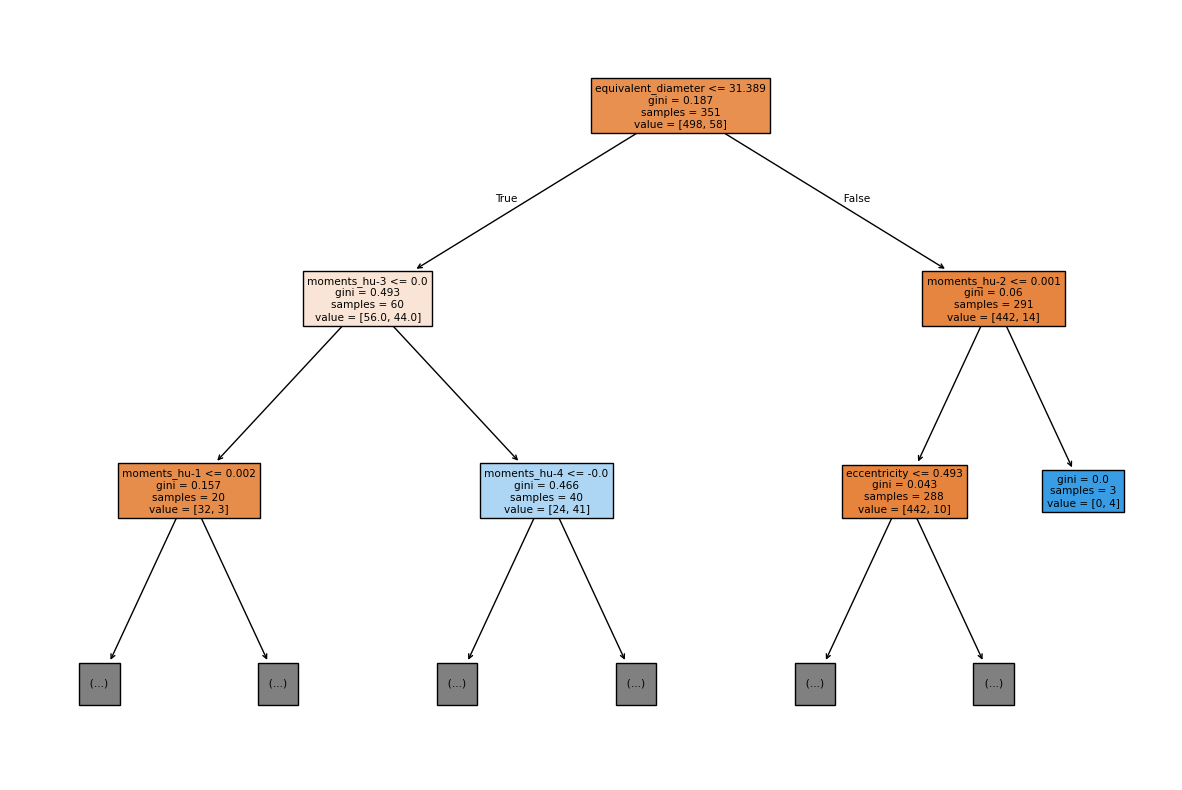

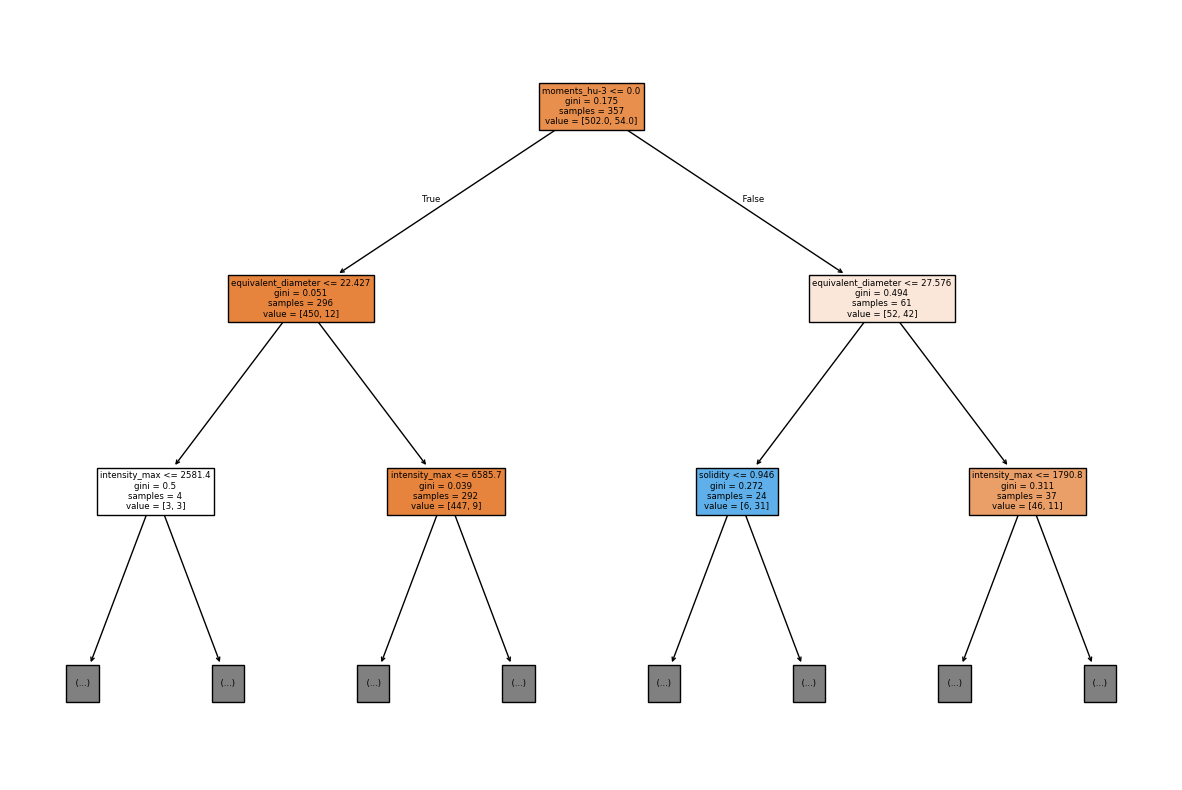

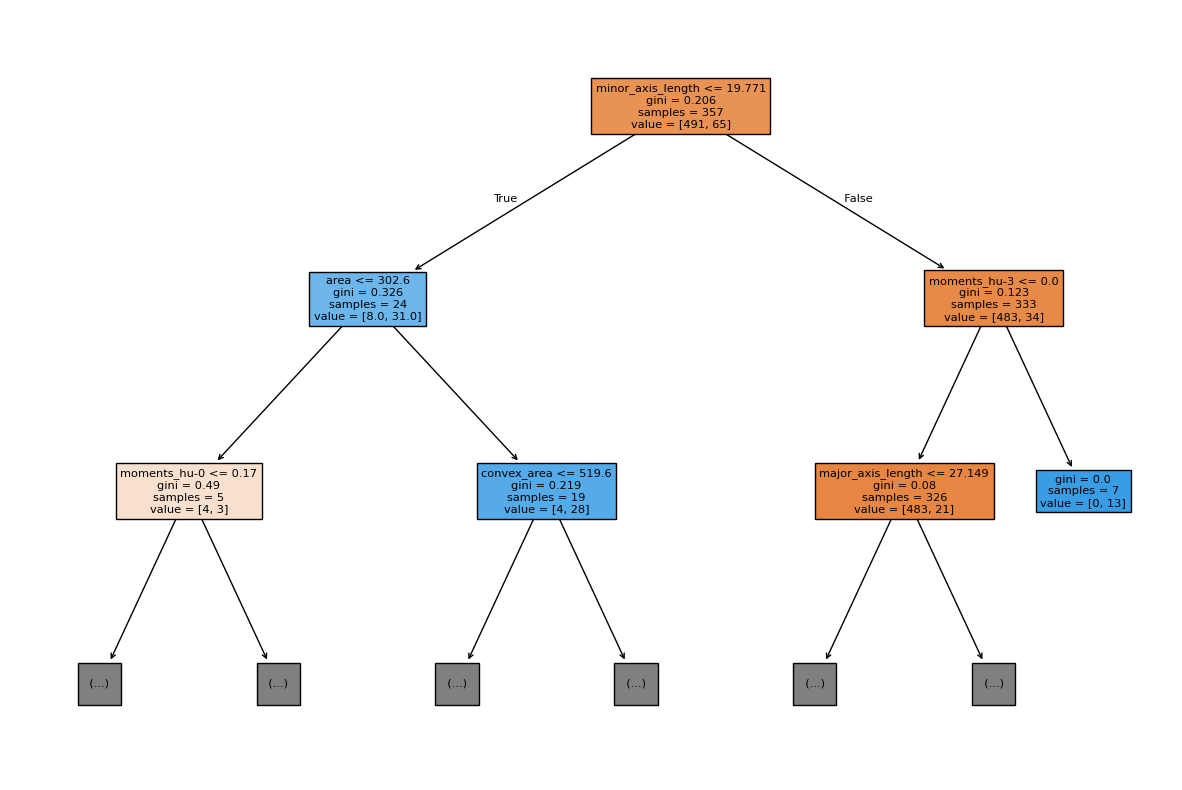

In [43]:
from sklearn import tree
import matplotlib.pyplot as plt

# For a single tree
plt.figure(figsize=(15, 10))
tree.plot_tree(rf.estimators_[0], 
               feature_names=X_train.columns,  
               filled=True, 
               max_depth=2)
plt.show()

plt.figure(figsize=(15, 10))
tree.plot_tree(rf.estimators_[1], 
               feature_names=X_train.columns,  
               filled=True, 
               max_depth=2)
plt.show()

plt.figure(figsize=(15, 10))
tree.plot_tree(rf.estimators_[2], 
               feature_names=X_train.columns,  
               filled=True, 
               max_depth=2)
plt.show()


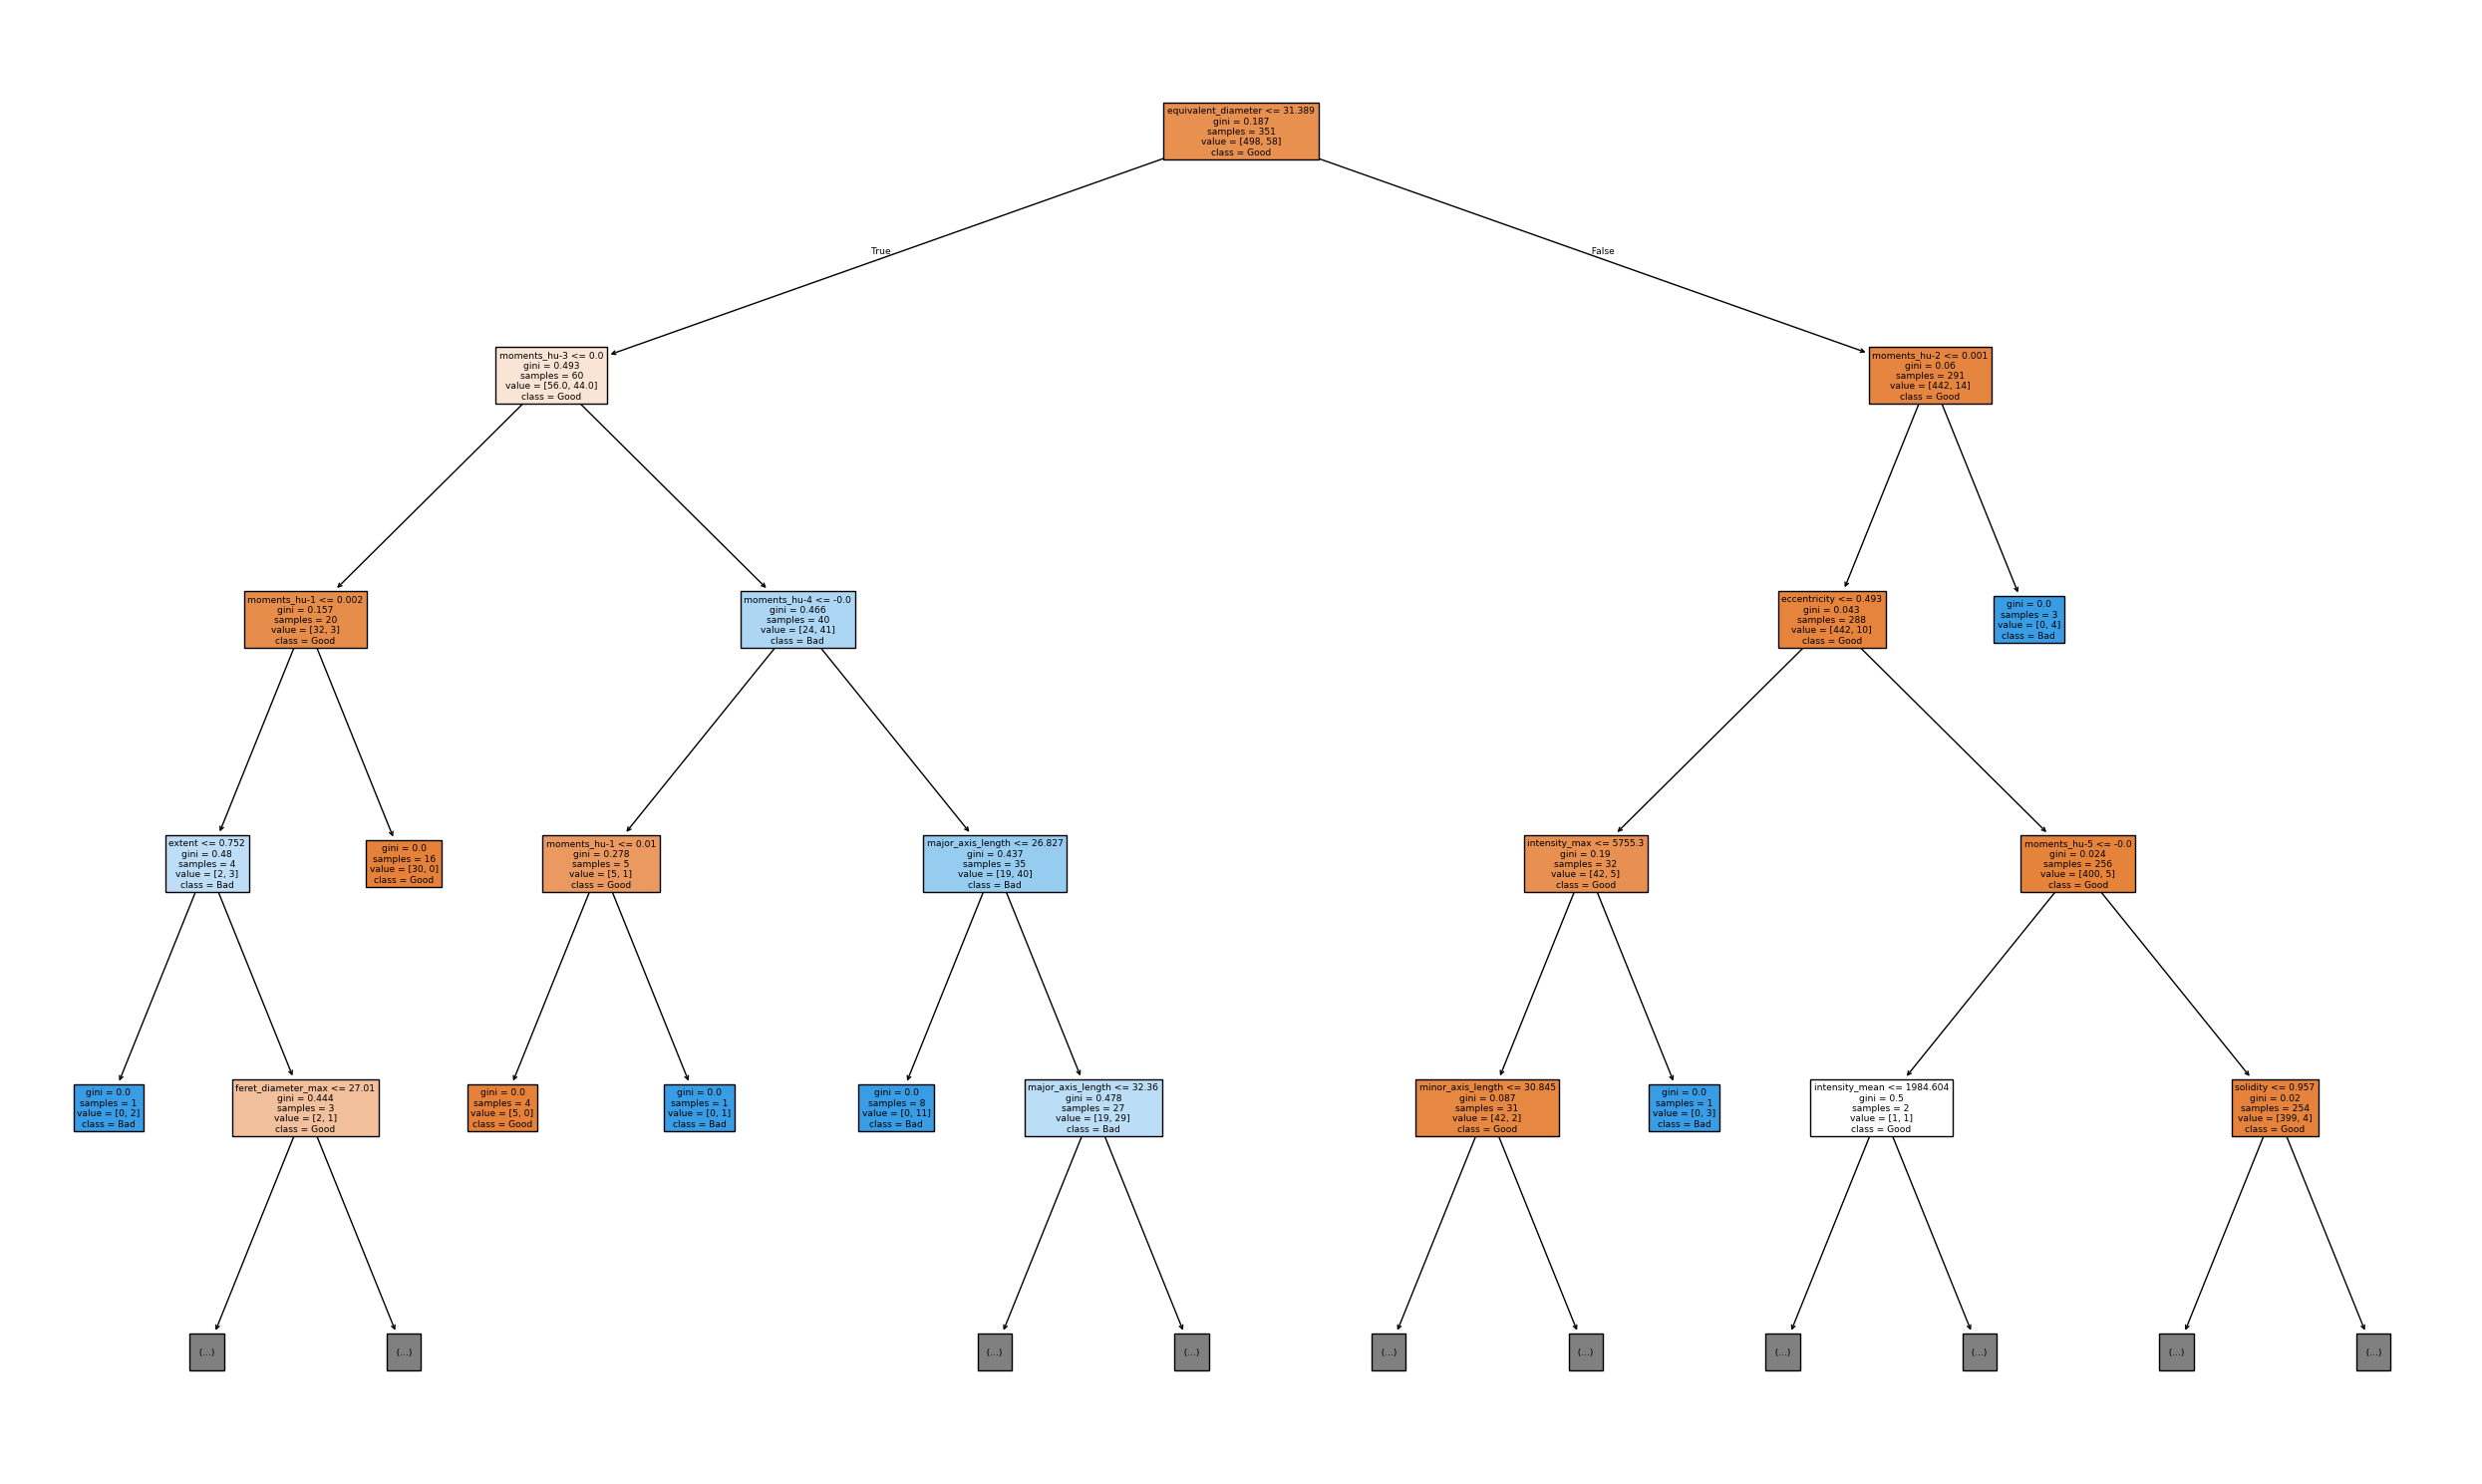

In [44]:
plt.figure(figsize=(25, 15))

tree.plot_tree(rf.estimators_[0], 
               feature_names=X_train.columns,  
               filled=True,
               max_depth=4,
               class_names=['Good', 'Bad', 'Mitotic'])

plt.tight_layout()
plt.show()

In [46]:
param_dist = {'n_estimators': randint(50,1000),
              'max_depth': randint(1,20)}

# Create a random forest classifier
rf = RandomForestClassifier()

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(rf, 
                                 param_distributions = param_dist, 
                                 n_iter=5, 
                                 cv=5)

# Fit the random search object to the data
rand_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=5,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7533079b9c00>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7533079bba00>})

In [47]:
# Create a variable for the best model
best_rf = rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  rand_search.best_params_)

Best hyperparameters: {'max_depth': 14, 'n_estimators': 565}


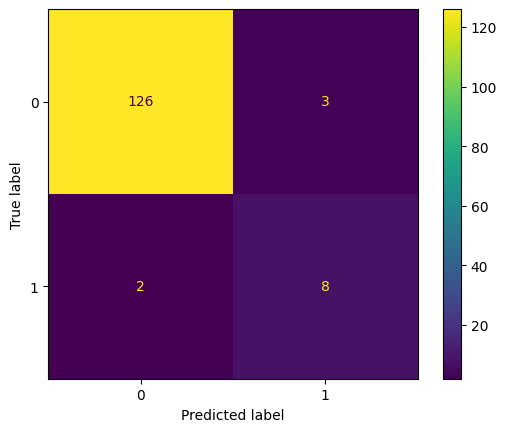

In [48]:
# Generate predictions with the best model
y_pred = best_rf.predict(X_test)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot();

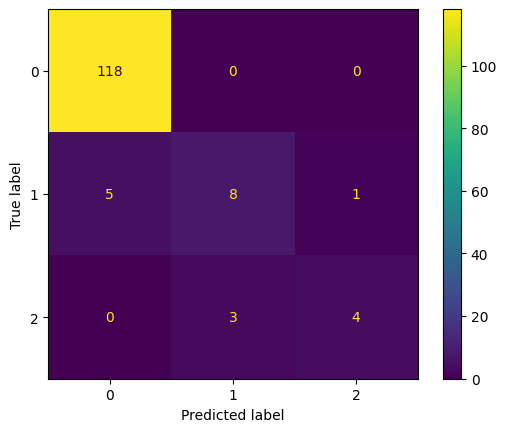

In [44]:
# Generate predictions with the best model
y_pred = best_rf.predict(X_test)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot();

In [74]:
#rf = RandomForestClassifier(max_depth=3, n_estimators=347)
#rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, n_estimators=347)

In [49]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9640287769784173


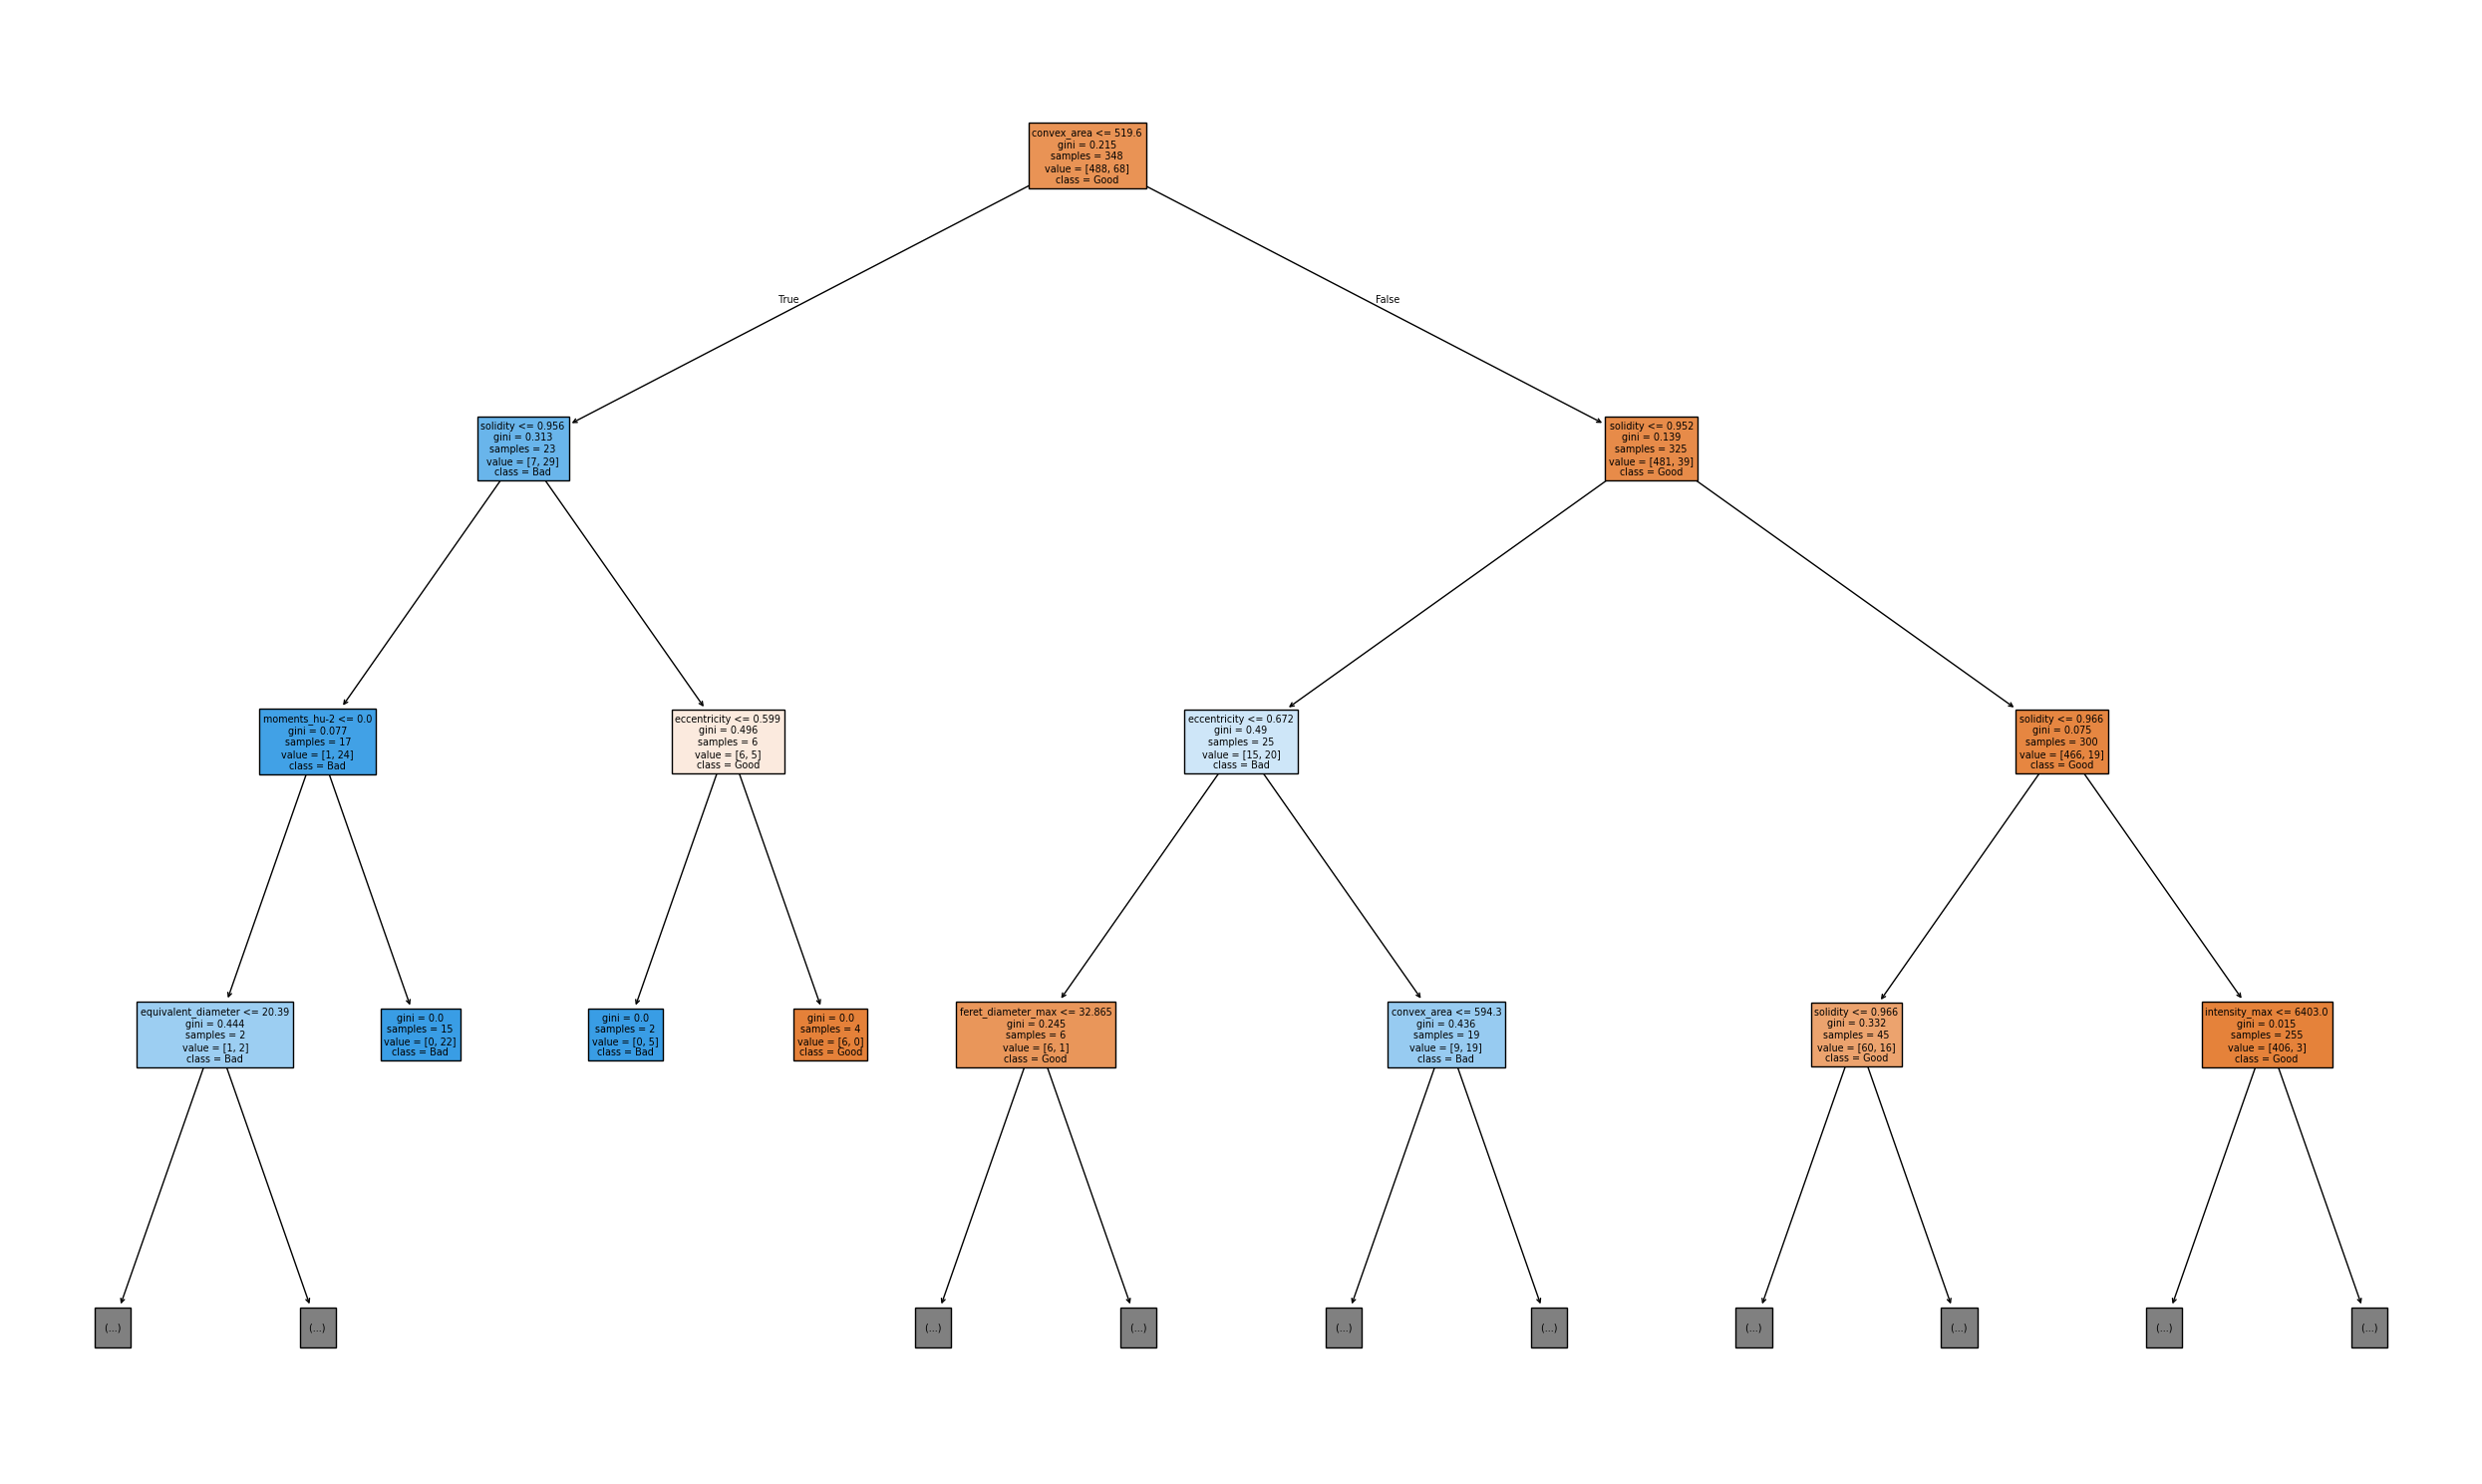

In [50]:
plt.figure(figsize=(25, 15))

tree.plot_tree(best_rf.estimators_[0], 
               feature_names=X_train.columns,  
               filled=True,
               max_depth=3,
               class_names=['Good', 'Bad', 'Mitotic'])

plt.tight_layout()
plt.show()

In [51]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       129
           1       0.73      0.80      0.76        10

    accuracy                           0.96       139
   macro avg       0.86      0.89      0.87       139
weighted avg       0.97      0.96      0.96       139



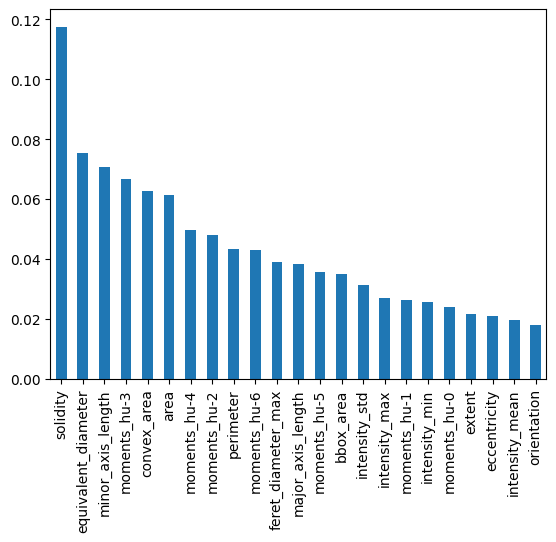

In [52]:
# Create a series containing feature importances from the model and feature names from the training data 
# 2 class model
feature_importances = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Plot a simple bar chart
feature_importances.plot.bar();

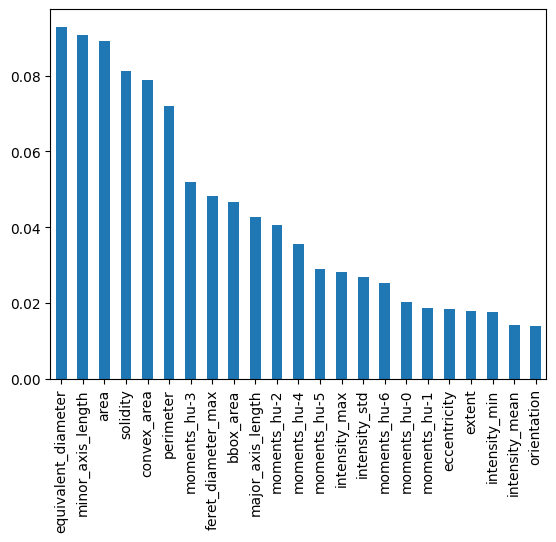

In [37]:
# Create a series containing feature importances from the model and feature names from the training data
feature_importances = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Plot a simple bar chart
feature_importances.plot.bar();

In [54]:
from joblib import dump, load

# Save the best_rf model to a file
dump(best_rf, '/home/nbahou/myimaging/apoDet/best_rf_model_40x.joblib')

# Later, load the model in another script:
# best_rf = load('best_rf_model.joblib')


['/home/nbahou/myimaging/apoDet/best_rf_model_40x.joblib']

## Reduced Features

In [39]:
feature_importances.index[:10]

Index(['equivalent_diameter', 'area', 'convex_area', 'minor_axis_length',
       'solidity', 'bbox_area', 'perimeter', 'feret_diameter_max',
       'moments_hu-3', 'moments_hu-4'],
      dtype='object')

In [41]:
top10_features = features[feature_importances.index[:10]]

X_train, X_test, y_train, y_test = train_test_split(top10_features, class_labels, test_size=0.2)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)


RandomForestClassifier()

In [42]:
y_pred = rf.predict(X_test)

In [43]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9064748201438849


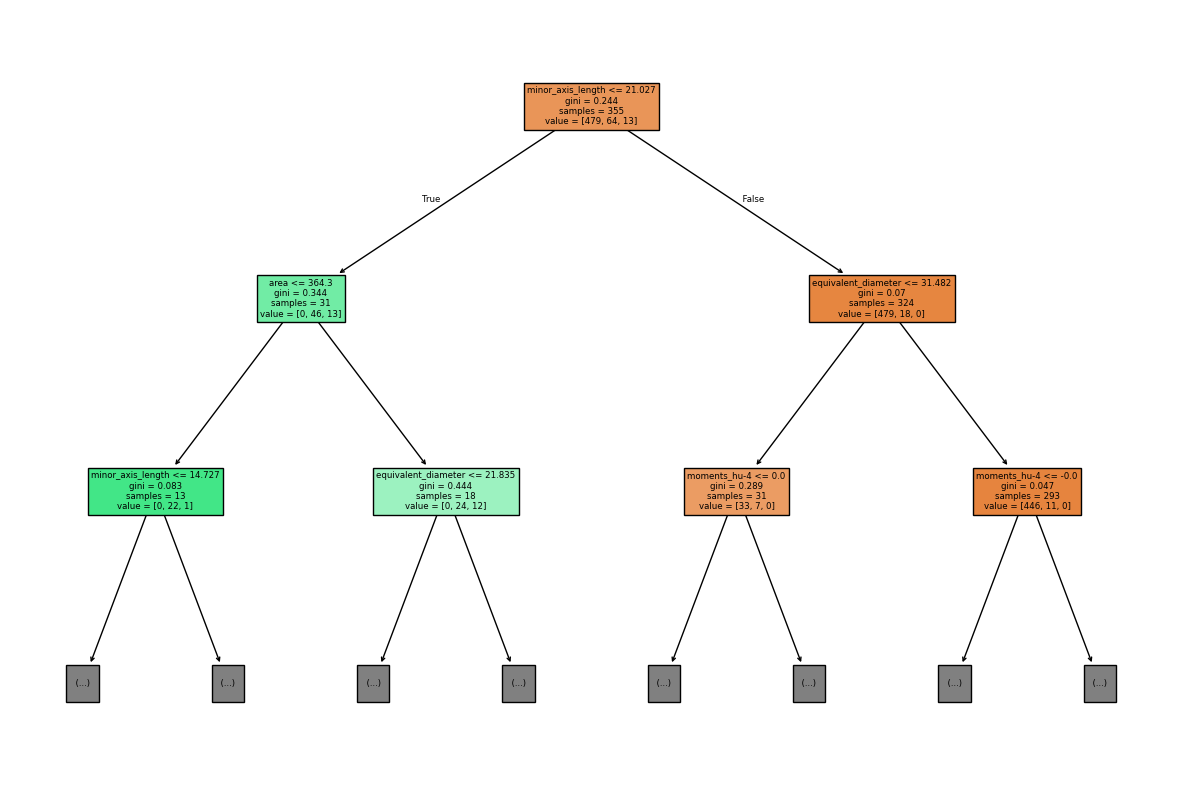

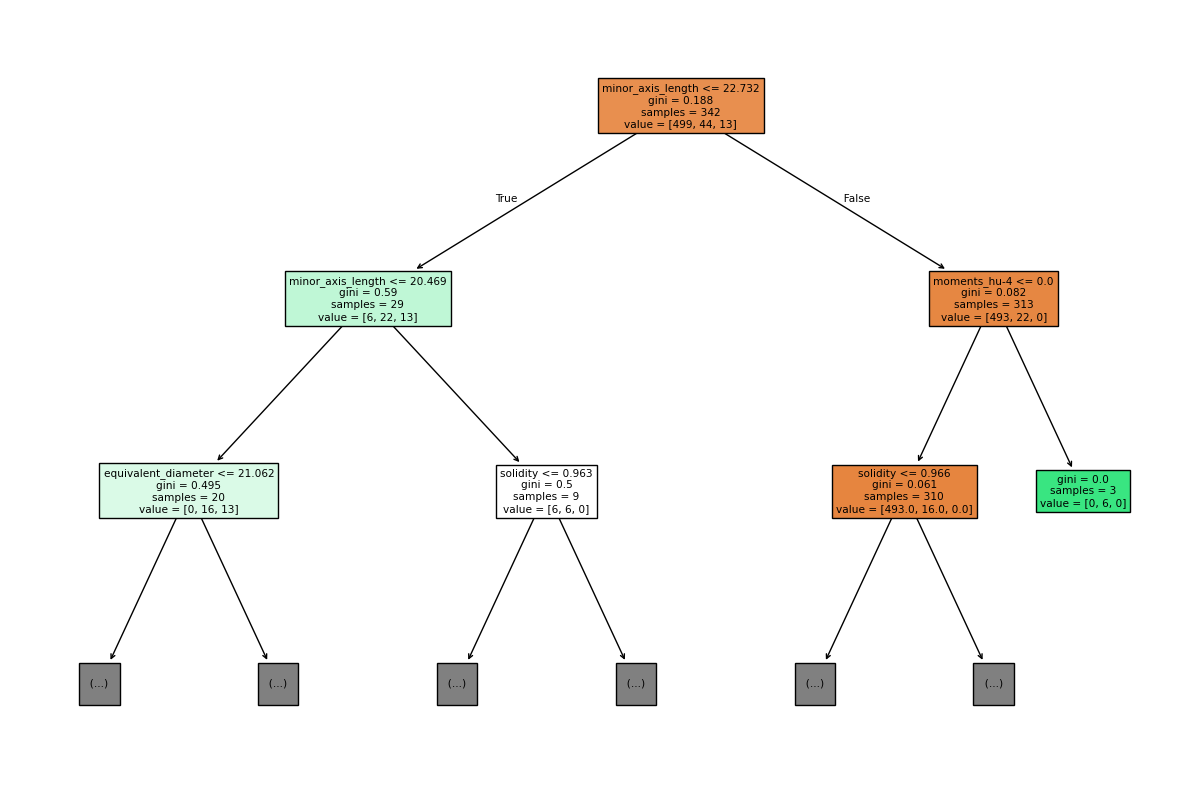

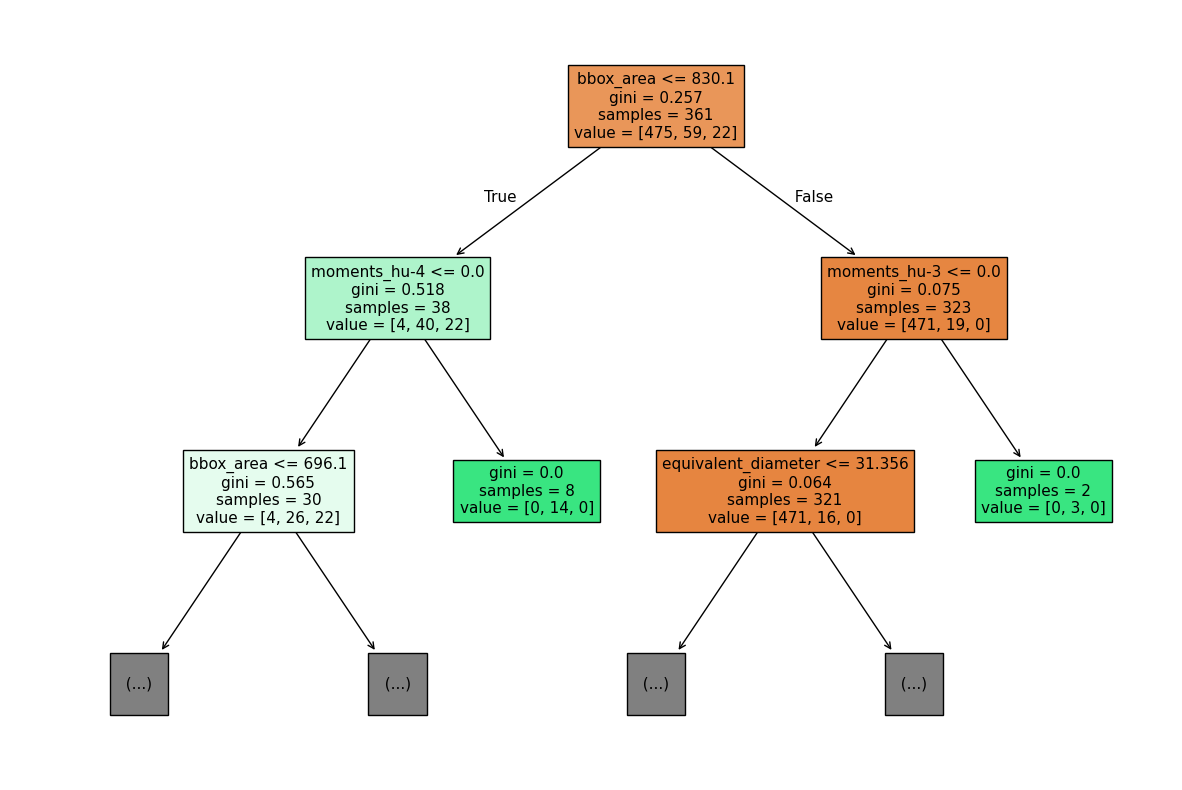

In [44]:
from sklearn import tree
import matplotlib.pyplot as plt

# For a single tree
plt.figure(figsize=(15, 10))
tree.plot_tree(rf.estimators_[0], 
               feature_names=X_train.columns,  
               filled=True, 
               max_depth=2)
plt.show()

plt.figure(figsize=(15, 10))
tree.plot_tree(rf.estimators_[1], 
               feature_names=X_train.columns,  
               filled=True, 
               max_depth=2)
plt.show()

plt.figure(figsize=(15, 10))
tree.plot_tree(rf.estimators_[2], 
               feature_names=X_train.columns,  
               filled=True, 
               max_depth=2)
plt.show()


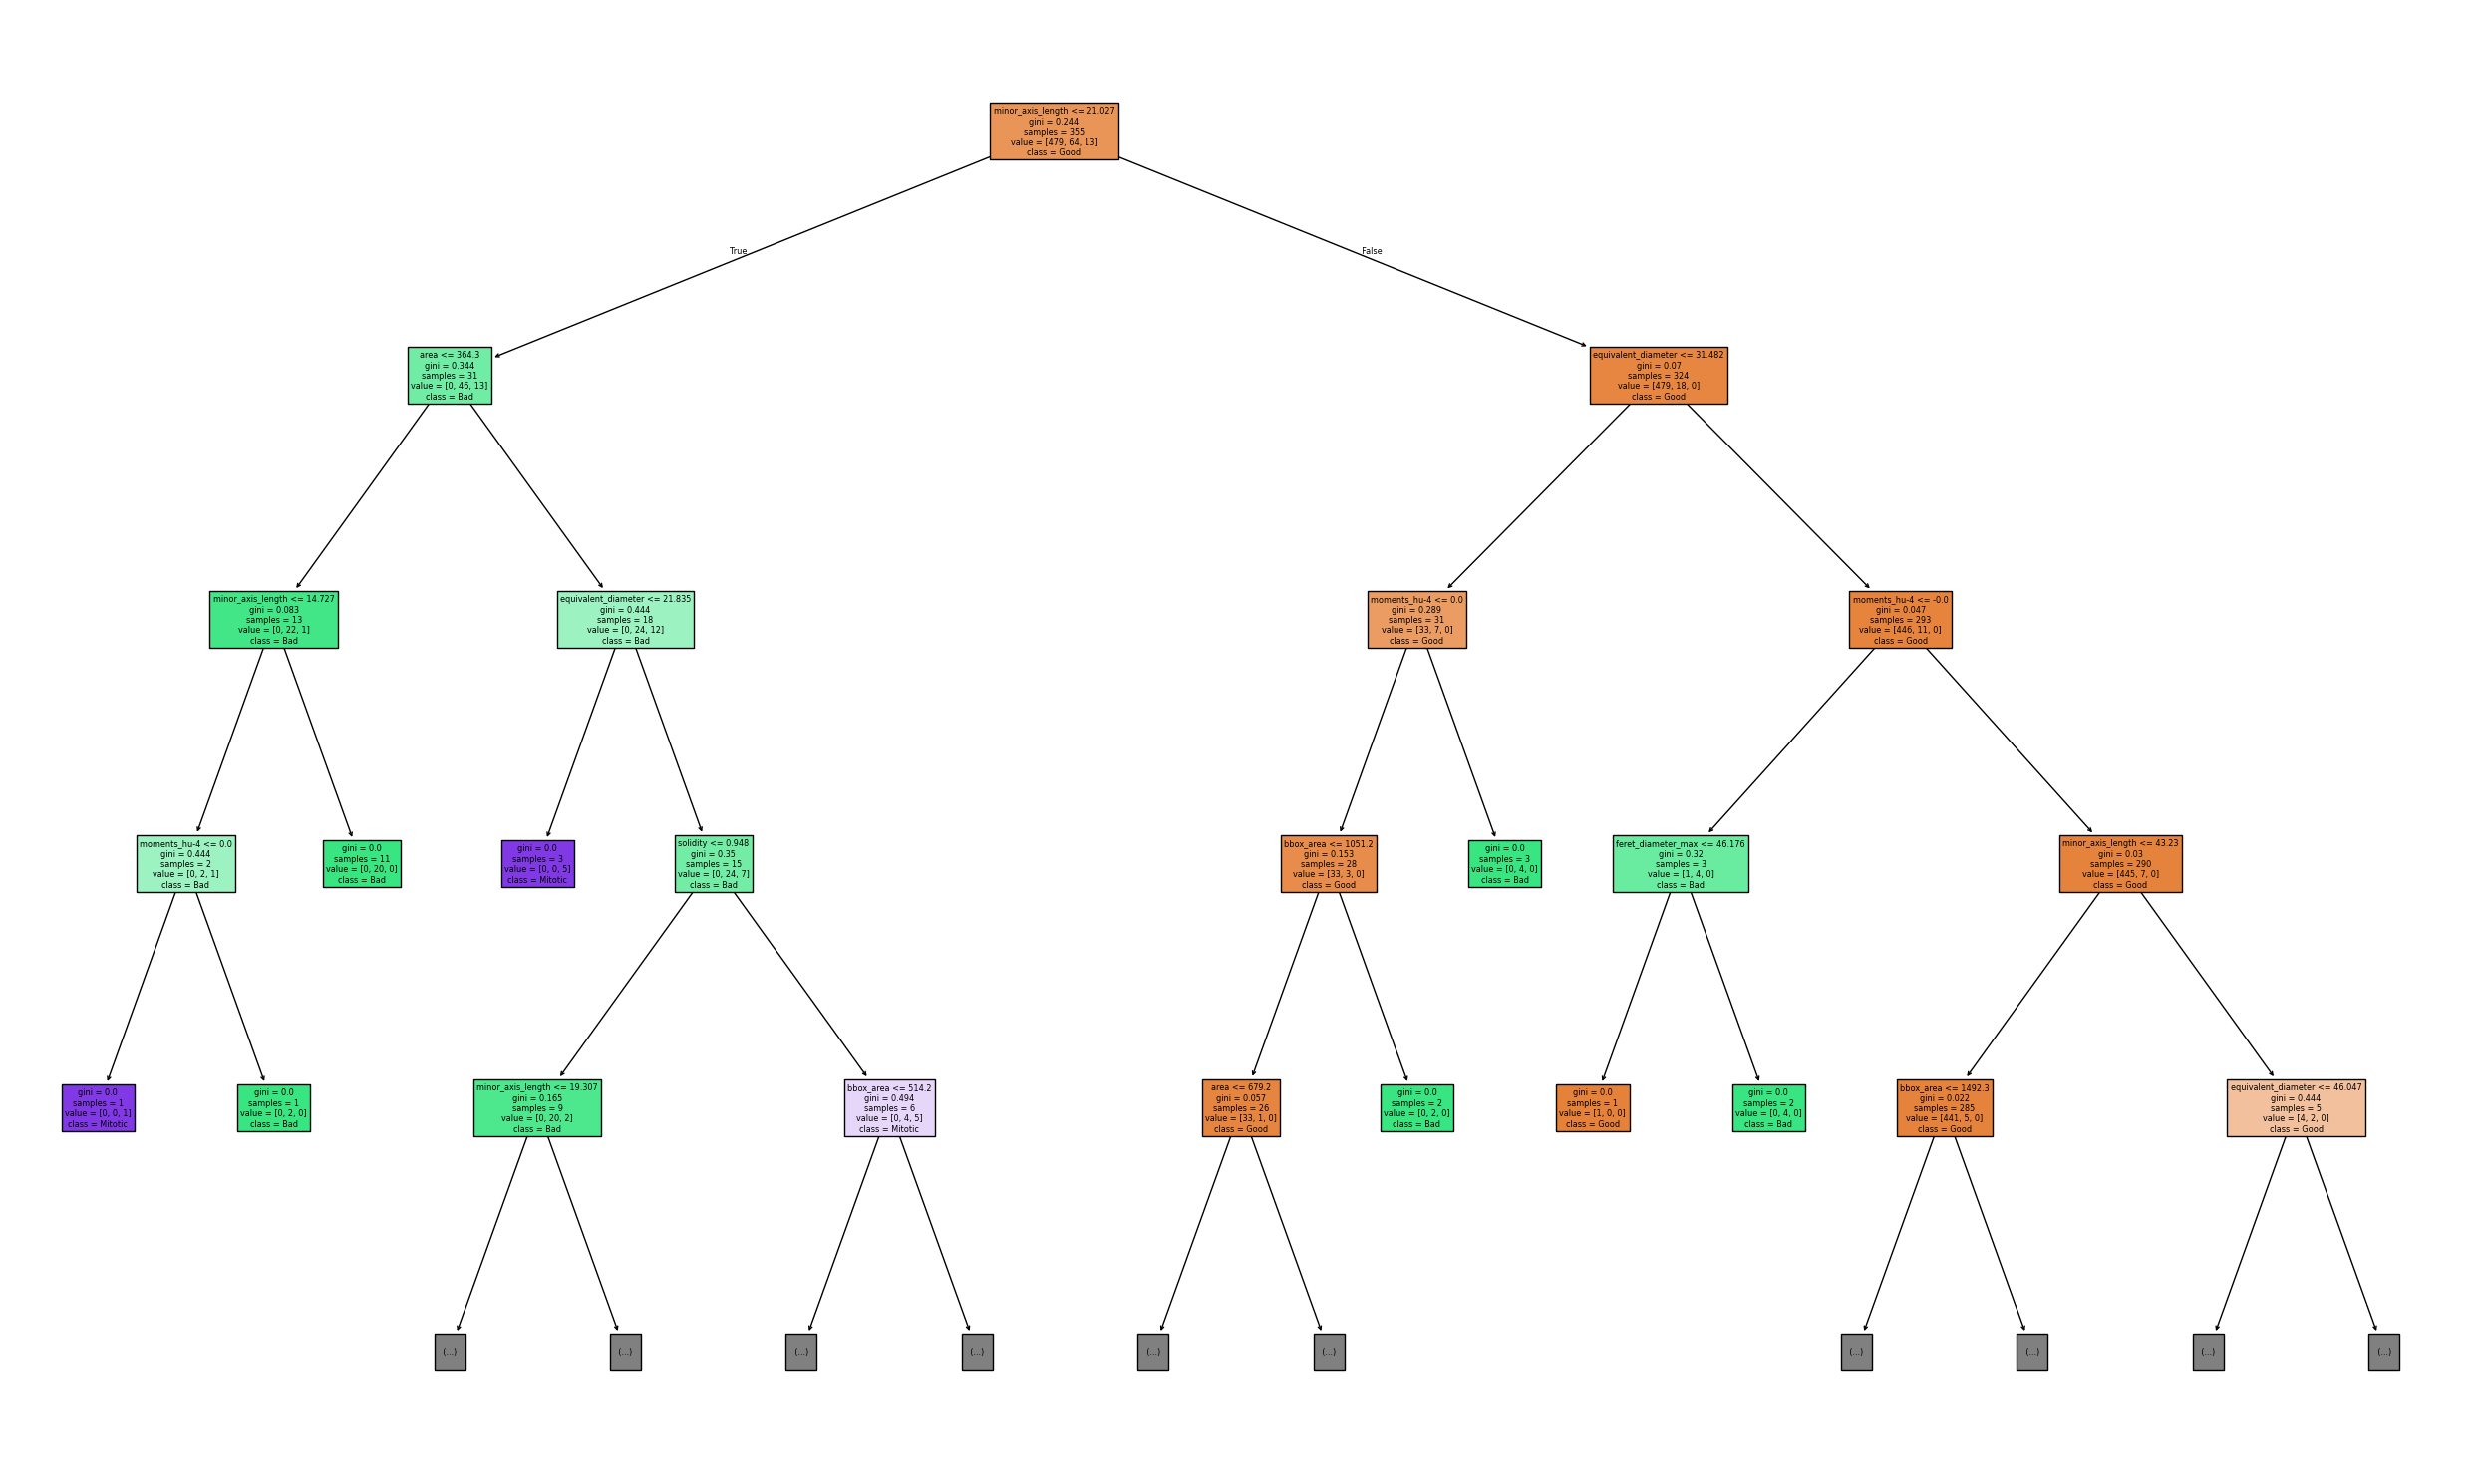

In [45]:
plt.figure(figsize=(25, 15))

tree.plot_tree(rf.estimators_[0], 
               feature_names=X_train.columns,  
               filled=True,
               max_depth=4,
               class_names=['Good', 'Bad', 'Mitotic'])

plt.tight_layout()
plt.show()

In [46]:
param_dist = {'n_estimators': randint(50,500),
              'max_depth': randint(1,20)}

# Create a random forest classifier
rf = RandomForestClassifier()

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(rf, 
                                 param_distributions = param_dist, 
                                 n_iter=5, 
                                 cv=5)

# Fit the random search object to the data
rand_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=5,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x719785e35060>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7197861e73a0>})

In [47]:
# Create a variable for the best model
best_rf = rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  rand_search.best_params_)

Best hyperparameters: {'max_depth': 19, 'n_estimators': 58}


In [48]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       115
           1       0.60      0.60      0.60        15
           2       0.71      0.56      0.62         9

    accuracy                           0.91       139
   macro avg       0.76      0.71      0.73       139
weighted avg       0.90      0.91      0.90       139



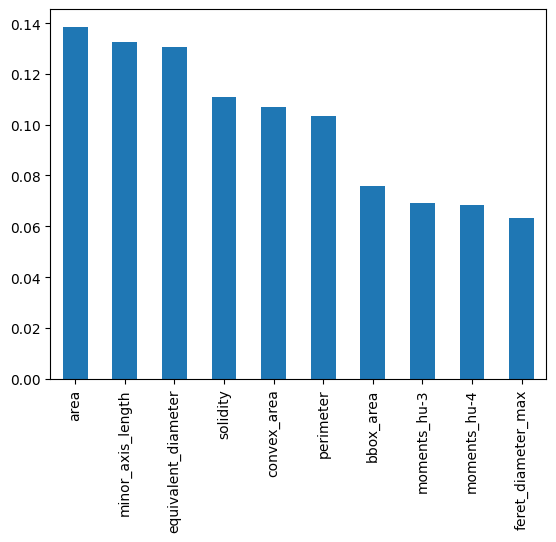

In [49]:
# Create a series containing feature importances from the model and feature names from the training data
feature_importances = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Plot a simple bar chart
feature_importances.plot.bar();

In [50]:
top10_features = features[feature_importances.index[:10]]

X_train, X_test, y_train, y_test = train_test_split(top10_features, class_labels, test_size=0.2)

rf = RandomForestClassifier(max_depth=19, n_estimators=58)
rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=19, n_estimators=58)

In [51]:
y_pred = rf.predict(X_test)

In [52]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       124
           1       0.62      0.45      0.53        11
           2       0.50      0.50      0.50         4

    accuracy                           0.93       139
   macro avg       0.70      0.65      0.67       139
weighted avg       0.92      0.93      0.92       139



In [26]:
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

In [ ]:
# To visualize multiple trees
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
for i, ax in enumerate(axes.flatten()):
    tree.plot_tree(rf.estimators_[i], 
                   feature_names=X_train.columns,
                   filled=True, 
                   max_depth=2, 
                   ax=ax)
    ax.set_title(f"Tree #{i}")
plt.tight_layout()
plt.show()

In [13]:
# Export the first three decision trees from the forest

for i in range(3):
    tree = rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train.columns,  
                               filled=True,  
                               max_depth=2, 
                               impurity=False, 
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [5]:
X_test

,area,perimeter,bbox_area,convex_area,eccentricity,equivalent_diameter,extent,feret_diameter_max,major_axis_length,minor_axis_length,...,intensity_std,intensity_max,intensity_min,moments_hu-0,moments_hu-1,moments_hu-2,moments_hu-3,moments_hu-4,moments_hu-5,moments_hu-6
270,944.4,114.580317,1208.8,970.4,0.619293,34.672176,0.781729,41.236746,39.268272,30.817931,...,795.097816,4666.2,907.4,0.164951,0.001543,0.000055,1.866711e-06,1.996003e-11,6.893344e-08,-3.583561e-12
773,1158.6,130.011183,1574.2,1192.8,0.705976,38.407297,0.737142,47.350388,46.074884,32.610368,...,229.886851,1843.0,521.8,0.171910,0.003280,0.000278,6.613832e-06,-2.839235e-10,-3.453404e-07,1.004404e-10
914,1100.2,123.279812,1422.2,1129.4,0.625723,37.426541,0.773733,43.439944,42.486282,33.001711,...,505.017324,2557.2,386.4,0.164519,0.001722,0.000004,8.251890e-08,5.771234e-14,1.678359e-09,6.738985e-14
789,1001.8,127.678593,1477.8,1061.8,0.817883,35.698417,0.679876,49.949738,48.118679,27.465658,...,208.679813,1587.4,410.0,0.191977,0.009754,0.000410,5.818287e-05,7.147569e-09,2.757799e-06,7.566915e-09
323,888.8,112.402857,1208.4,915.8,0.696627,33.637640,0.736942,40.888341,39.911617,28.611911,...,216.652643,1505.2,372.4,0.169610,0.002974,0.000143,4.275408e-06,8.743128e-11,1.566851e-07,6.662986e-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
734,1034.0,123.643059,1358.0,1075.6,0.731811,36.282702,0.762500,44.687272,44.294223,30.158748,...,332.927268,2545.8,689.2,0.173600,0.004060,0.000134,6.144061e-06,-6.434216e-11,-1.502770e-07,1.727095e-10
716,941.4,114.140115,1227.4,967.8,0.620634,34.616484,0.767317,39.755324,39.216253,30.658309,...,160.104827,1573.8,426.0,0.164590,0.001611,0.000016,2.618267e-07,-6.015318e-14,-1.235552e-11,-2.563599e-13
872,1208.2,132.827835,1717.6,1237.8,0.764271,39.220600,0.703541,49.509906,49.012015,31.603204,...,228.659229,1920.6,543.0,0.175948,0.005277,0.000126,8.108529e-06,2.700354e-10,5.759676e-07,-4.835370e-11
931,438.6,80.895036,660.6,462.0,0.792701,23.454103,0.658221,31.236037,30.545909,18.288175,...,698.699141,3824.0,1016.2,0.184397,0.008054,0.000105,5.698510e-06,7.770273e-11,2.814416e-07,1.973934e-11


In [14]:
df_first

,label,x,y,t,filename,status
1,3.0,70.0,678.0,0.0,cell_Exp01_Site01_3.tif,0
2,4.0,282.0,680.0,0.0,cell_Exp01_Site01_4.tif,0
3,5.0,106.0,680.0,0.0,cell_Exp01_Site01_5.tif,0
4,6.0,400.0,682.0,0.0,cell_Exp01_Site01_6.tif,0
5,7.0,130.0,670.0,0.0,cell_Exp01_Site01_7.tif,0
...,...,...,...,...,...,...
1077,4807.0,846.0,494.0,1240.0,cell_Exp01_Site02_4807.tif,0
1082,5038.0,532.0,392.0,1300.0,cell_Exp01_Site02_5038.tif,0
1090,5269.0,406.0,98.0,1359.0,cell_Exp01_Site02_5269.tif,1
1092,5362.0,746.0,488.0,1382.0,cell_Exp01_Site02_5362.tif,1


In [15]:
features

,area,perimeter,bbox_area,convex_area,eccentricity,equivalent_diameter,extent,feret_diameter_max,major_axis_length,minor_axis_length,...,intensity_std,intensity_max,intensity_min,moments_hu-0,moments_hu-1,moments_hu-2,moments_hu-3,moments_hu-4,moments_hu-5,moments_hu-6
1,535.8,87.412193,729.0,559.0,0.711725,26.101056,0.734549,31.819688,31.363155,21.969129,...,317.459238,2278.6,855.6,0.171464,0.003521,0.000136,4.362647e-06,1.382096e-10,1.527975e-07,8.814754e-11
2,868.4,110.499913,1192.6,892.0,0.708009,33.250097,0.728878,40.495959,39.669098,28.011735,...,384.001099,2650.4,759.6,0.169753,0.003228,0.000074,2.460770e-06,2.144543e-11,7.548227e-08,3.260414e-11
3,940.0,113.105801,1217.2,966.2,0.406235,34.593611,0.772738,38.092565,36.285141,33.128344,...,608.736882,4469.0,1030.4,0.160535,0.000217,0.000045,8.770938e-08,1.581615e-13,7.753135e-10,-1.534724e-13
4,969.2,117.142554,1338.0,996.0,0.721426,35.126455,0.724716,42.849462,42.337732,29.287702,...,264.374967,2065.6,493.0,0.170988,0.003669,0.000059,2.492890e-06,2.335440e-11,6.143144e-08,-5.446163e-11
5,455.4,81.715137,649.4,480.4,0.677691,24.058370,0.700477,29.578427,28.633786,20.886221,...,1094.937734,6032.4,1380.4,0.173176,0.003057,0.000497,2.476654e-05,2.538570e-09,9.309899e-07,-2.263086e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1077,1588.4,147.251385,1915.8,1613.2,0.585872,44.683610,0.822744,52.120864,49.883942,40.430468,...,426.396000,2446.6,575.6,0.164727,0.001320,0.000098,2.123670e-06,5.886179e-11,9.252146e-08,1.186546e-11
1082,1421.0,146.314127,1908.8,1460.4,0.717142,42.528522,0.744473,53.573715,51.448525,35.790133,...,337.188245,2472.4,405.2,0.172823,0.003630,0.000129,8.489911e-06,2.592206e-10,2.340782e-07,-2.140188e-10
1090,700.0,113.340115,1194.0,780.0,0.874295,29.841242,0.590511,44.789393,44.739743,21.651391,...,122.794174,1001.8,359.6,0.220666,0.018823,0.001790,1.936200e-04,1.925138e-09,-5.734333e-06,1.210866e-07
1092,1109.8,128.334228,1513.2,1151.2,0.660963,37.568513,0.736460,45.752839,44.067189,33.030443,...,272.465051,1809.6,392.6,0.171052,0.002338,0.000447,9.982722e-06,-1.707810e-10,-1.222368e-07,-3.737063e-10


In [16]:
np.unique(class_labels)

array([0, 1, 2])